# 1. Molecular Docking Analysis

This notebook performs molecular docking analysis of chalcone derivatives against the FRD (Flavin Reductase Domain) protein using rDock. The workflow includes:
- Chalcone structure preparation from SMILES
- Molecular docking with rDock
- Results processing and visualization

## 1.1 Load Chalcone Database

Load the chalcone database containing SMILES strings for all chalcone derivatives to be docked.

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [15]:
df = pd.read_csv('./docking/chalcone_preparation/chalcone-DB.csv')
df.head()


,Chalcone-ID,Paper-ID,Chalcone-SMILE
0,ID-01,13a,O=C(/C=C/C1=CC(OC)=C(OC(C)=C2)C2=C1)C3=CC=CC=C3
1,ID-02,13b,O=C(/C=C/C1=CC(OC)=C(OC(C)=C2)C2=C1)C3=CC=CC=C3F
2,ID-03,13c,O=C(/C=C/C1=CC(OC)=C(OC(C)=C2)C2=C1)C3=CC=CC(F...
3,ID-04,13d,O=C(/C=C/C1=CC(OC)=C(OC(C)=C2)C2=C1)C3=CC=C(F)...
4,ID-05,13e,O=C(/C=C/C1=CC(OC)=C(OC(C)=C2)C2=C1)C3=CC=CC=C3Cl


## 1.2 Generate 3D Structures from SMILES

Convert SMILES strings to 3D molecular structures using RDKit. Each structure is optimized with the UFF (Universal Force Field) and saved in SDF format for docking.

In [ ]:

# Read the CSV file
input_csv = "./docking/chalcone_preparation/chalcone-DB.csv"
output_sdf = "./docking/chalcone_preparation/chalcone-DB.sdf"

# Load CSV into DataFrame
df = pd.read_csv(input_csv)

# Create SDF writer
writer = Chem.SDWriter(output_sdf)

# Process each row in the DataFrame
for _, row in df.iterrows():
    chalcone_id = row['Chalcone-ID']  # Get ID
    smiles = row['Chalcone-SMILE']    # Get SMILES

    # Convert SMILES to molecule
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)  # Add hydrogens
    AllChem.EmbedMolecule(mol)  # Generate initial conformation
    AllChem.UFFOptimizeMolecule(mol)  # Optimize geometry with UFF

    # Add ID as molecule property
    mol.SetProp("Chalcone-ID", chalcone_id)

    # Write optimized molecule to SDF
    writer.write(mol)

# Close SDF writer
writer.close()

print(f"Optimization completed. Optimized molecules saved to {output_sdf}")

## 1.3 Chalcone ID Mapping

Dictionary mapping internal IDs to Paper IDs for result interpretation.

In [ ]:
### ID Mapping Reference Table

This table maps internal sequential IDs (used in the chalcone database) to their corresponding Paper IDs as referenced in the publication.

| ID  | Paper-ID | ID  | Paper-ID | ID  | Paper-ID |
|-----|----------|-----|----------|-----|----------|
| 1   | 13a      | 13  | 13m      | 25  | 14i      |
| 2   | 13b      | 14  | 13n      | 26  | 14j      |
| 3   | 13c      | 15  | 13o      | 27  | 14k      |
| 4   | 13d      | 16  | 13p      | 28  | 14l      |
| 5   | 13e      | 17  | 13q      | 29  | 14m      |
| 6   | 13f      | 18  | 14a      | 30  | 14n      |
| 7   | 13g      | 19  | 14b      | 31  | 14o      |
| 8   | 13h      | 20  | 14c      | 32  | 14p      |
| 9   | 13i      | 21  | 14d      | 33  | 14q      |
| 10  | 13j      | 22  | 14e      | 34  | 15       |
| 11  | 13k      | 23  | 14f      |     |          |
| 12  | 13l      | 24  | 14g      |     |          |

**Total compounds:** 34 chalcone derivatives

## 1.4 Run Molecular Docking

Execute rDock to perform molecular docking of all chalcone derivatives against the FRD binding pocket. The script:
- Configures the binding cavity
- Performs docking with 100 poses per ligand
- Sorts and filters unique poses by docking score
- Exports results and individual PDB files

In [ ]:
%%writefile run-rDock.sh

#!/bin/bash
#
# Molecular Docking Pipeline for Chalcone Database using rDock
# This script performs the complete docking workflow including:
# - Cavity configuration
# - Docking execution (100 poses per ligand)
# - Result post-processing and filtering
# - Output format conversion
#

set -e  # Exit on error

echo "Starting rDock docking pipeline..."

# Navigate to docking directory
cd ./docking

# Step 1: Configure binding cavity in FRD pocket
echo "[1/6] Configuring binding cavity..."
rbcavity --was -d -r good.prm

# Step 2: Run molecular docking
echo "[2/6] Running rDock (100 poses per ligand)..."
rbdock -i ./chalcone-DB.sdf -o ./output_rDock/docking_out -r good.prm -p dock.prm -n 100 > ./output_rDock/docking_out.log

# Step 3: Rename output file to SDF format
echo "[3/6] Renaming output file..."
mv ./output_rDock/docking_out.sd ./output_rDock/docking_out.sdf

# Step 4: Sort poses by docking score
echo "[4/6] Sorting by docking score..."
sdsort -n -f'SCORE' ./output_rDock/docking_out.sdf > ./output_rDock/docking_out_sorted.sdf

# Step 5: Remove duplicate poses based on connectivity
echo "[5/6] Removing duplicate conformations..."
obabel ./output_rDock/docking_out_sorted.sdf -O ./output_rDock/docking_out_sorted_unique.sdf --unique /connect

# Step 6: Final sort after deduplication
sdsort -n -f'SCORE' ./output_rDock/docking_out_sorted_unique.sdf > ./output_rDock/docking_out_sorted_ok.sdf

# Step 7: Export best poses to PDB format (individual files)
echo "[6/6] Exporting poses to PDB format..."
obabel ./output_rDock/docking_out_sorted_ok.sdf -O ./output_poses/molecule.pdb -m

# Step 8: Generate results CSV file
echo "Generating results CSV..."
sdreport ./output_rDock/docking_out_sorted_ok.sdf > ./output_rDock/sdreport_results.csv

echo "Docking pipeline completed successfully!"
echo "Results saved in: ./output_rDock/"
echo "PDB poses saved in: ./output_poses/"

In [ ]:
!bash run-rDock.sh

## 1.5 Rename Docked Poses

Rename the output PDB files from generic names (molecule1.pdb, molecule2.pdb...) to their corresponding Paper IDs (13a, 14c, etc.) for easier identification.

In [ ]:
%%writefile chalcones_docking_rename.sh

#!/bin/bash

set -e

cd ./docking/output_poses

names=(13c 14g 13a 14a	14e 14f	14c 13e	13b 14o	14d 14i	13k 13g	13f 14j	15 13h	14k 13n	13i 13d 14b 13l	13o 14l	13q 14m	13m 13j	14q 14p	14n 13p	)

# Initialize a counter to keep track of the molecule number
counter=1

for name in "${names[@]}"; do
  # Construct the current molecule file name
  current_file="molecule${counter}.pdb"
  
  # Construct the new file name
  new_file="${name}.pdb"
  
  # Move (rename) the file
  mv "$current_file" "$new_file"
  
  # Increment the counter
  ((counter++))
done


In [ ]:
!bash chalcones_docking_rename.sh

## 1.6 Visualize Docking Results

Process and visualize the docking scores from rDock output. The table shows:
- **Paper-ID**: Chalcone identifier from the paper
- **TOTAL**: Total docking score (lower is better)
- **INTER**: Intermolecular interaction energy
- **INTRA**: Intramolecular energy
- **VDW**: Van der Waals interaction energy

Results are sorted by total score to identify the best binders.

In [ ]:

# Read docking results from consolidated CSV
df_docking = pd.read_csv('./docking/results.csv')

# Correct the sign of Energy rstr (values in CSV are inverted)
df_docking['Energy rstr'] = df_docking['Energy rstr'] * -1

# Sort by Energy rstr score (best docking scores first - more negative is better)
df_docking = df_docking.sort_values('Energy rstr')

# Display results
print("="*80)
print("DOCKING RESULTS - Sorted by Docking Score")
print("="*80)
print(df_docking[['Paper-ID', 'Energy rstr', 'IC50', 'SI']].to_string(index=False))
print("\n" + "="*80)
print(f"Total chalcones analyzed: {len(df_docking)}")
print(f"Best binding chalcone: {df_docking.iloc[0]['Paper-ID']} (Score: {df_docking.iloc[0]['Energy rstr']:.2f} kcal/mol)")

# Find best IC50 (excluding NaN values)
df_with_ic50 = df_docking.dropna(subset=['IC50'])
if len(df_with_ic50) > 0:
    best_ic50 = df_with_ic50.nsmallest(1, 'IC50').iloc[0]
    print(f"Best IC50: {best_ic50['Paper-ID']} (IC50: {best_ic50['IC50']:.2f} µM)")
print("="*80)

# Save processed results
df_docking.to_csv('./docking/output_rDock/docking_results_processed.csv', index=False)
print("\nProcessed results saved to: ./docking/output_rDock/docking_results_processed.csv")

DOCKING RESULTS - Sorted by Docking Score
Paper-ID  Energy rstr  IC50     SI
     13c      -15.814 89.69 210.97
     14g      -15.182 86.73 139.28
     13a      -14.979 89.31 187.27
     14a      -14.950 87.85 156.74
     14e      -14.260 78.38 140.85
     14f      -14.176 56.26  97.85
     14c      -13.927 91.15 370.37
     13e      -13.864 90.87 462.96
     13b      -13.343 87.95 200.80
     14o      -13.148 63.62 257.73
     14d      -12.792 86.34 221.24
     14i      -12.521 70.18 223.21
     13k      -12.314 78.13 128.21
     13g      -12.145 78.12 126.58
     13f      -11.948 86.66 253.81
     14j       -9.687 24.41    NaN
      15       -9.212  2.41    NaN
     13h       -8.925 91.22 344.83
     14k       -8.755 46.24    NaN
     13n       -8.501 80.49 131.58
     13i       -8.184 74.61 151.52
     13d       -7.373 89.23 149.25
     14b       -6.756 90.36 188.68
     13l       -6.594 70.17 124.38
     13o       -6.374 87.32 220.26
     14l       -5.996 90.82 666.67
     13q     

## 1.7 Statistical Analysis and Correlation

Perform statistical analysis of docking results including:
- **Linear regression** between docking scores and IC50 values
- **Pearson correlation** to assess the relationship between computational predictions and experimental activity
- **Distribution analysis** of docking energies across all compounds

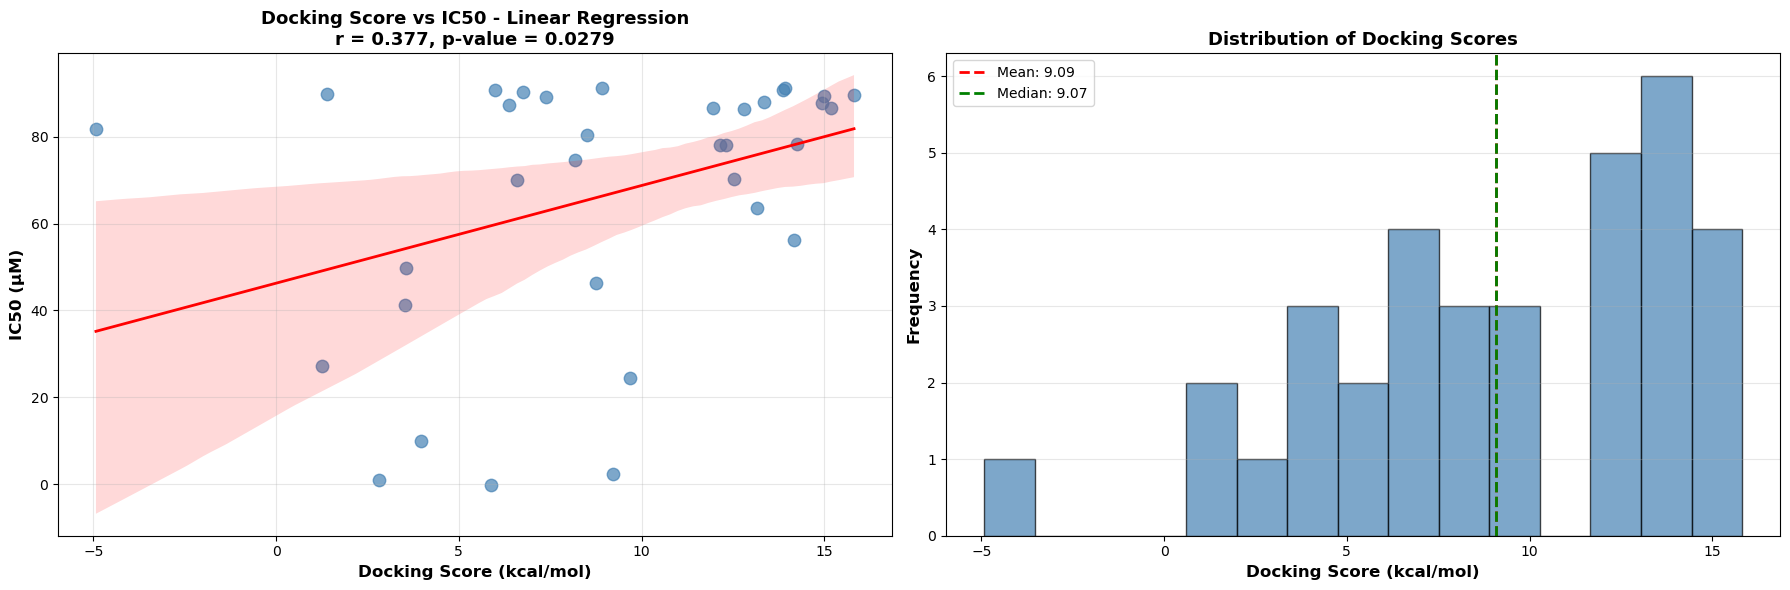


Statistical Summary:
Pearson correlation (r): 0.3772
P-value: 0.0279
Mean docking score: 9.09 kcal/mol
Median docking score: 9.07 kcal/mol
Standard deviation: 5.00 kcal/mol


In [ ]:

# Load docking results from CSV file
csv_file = "./docking/results.csv"
df = pd.read_csv(csv_file)

# Correct the sign of Energy rstr (values in CSV are inverted)
# In molecular docking, more negative values indicate better binding
df['Energy rstr'] = df['Energy rstr'] 

# Select required columns for analysis
df = df[["Paper-ID", "SMILE", "Energy rstr", "IC50"]]

# Calculate Pearson correlation between docking score and IC50
correlation, p_value = pearsonr(df["Energy rstr"], df["IC50"])

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Scatter plot with linear regression
sns.regplot(x=df["Energy rstr"], y=df["IC50"], 
            scatter_kws={"color": "steelblue", "s": 80, "alpha": 0.7}, 
            line_kws={"color": "red", "linewidth": 2}, 
            ax=axes[0])
axes[0].set_xlabel("Docking Score (kcal/mol)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("IC50 (µM)", fontsize=12, fontweight='bold')
axes[0].set_title(f"Docking Score vs IC50 - Linear Regression\nr = {correlation:.3f}, p-value = {p_value:.4f}", 
                  fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Plot 2: Histogram of docking energies
axes[1].hist(df["Energy rstr"], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Docking Score (kcal/mol)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Frequency", fontsize=12, fontweight='bold')
axes[1].set_title("Distribution of Docking Scores", fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# Add statistical information to histogram
mean_score = df["Energy rstr"].mean()
median_score = df["Energy rstr"].median()
axes[1].axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.2f}')
axes[1].axvline(median_score, color='green', linestyle='--', linewidth=2, label=f'Median: {median_score:.2f}')
axes[1].legend()

# Adjust layout and display
plt.tight_layout()
#plt.savefig("./docking/output_rDock/correlation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nStatistical Summary:")
print(f"{'='*50}")
print(f"Pearson correlation (r): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Mean docking score: {mean_score:.2f} kcal/mol")
print(f"Median docking score: {median_score:.2f} kcal/mol")
print(f"Standard deviation: {df['Energy rstr'].std():.2f} kcal/mol")
print(f"{'='*50}")